CPP Pricing Engine<br>
Alejandro Naranjo Caraza<br>
2026-03-01

#### Overview

The following code extracts data on AAPL Put / Call option contracts and uses the option pricing engine to extract implied volatilities and plot volatility smiles and surfaces. Note that Put and Call contracts are kept seperate, as are Out-of-the-Money (OTM) and In-the-Money (ITM) contracts.
Additionally, contracts are filtered based on the following criteria:

- Only ITM or OTM contracts are considered (not both). ITM Calls satisfy: *K < F*. OTM Calls satisfy: *K > F*
where *K* is the strike price and *F* is the underlying forward price.  

- Contracts with excessively large margins are excluded to avoid unrealistic prices.  

- Only contracts that satisfy no-arbitrage conditions are considered.

The no-arbitrage bounds for calls are
$$
\begin{aligned}
C_{\min} &= \max \big(F - K e^{-r T},\ 0 \big) &\quad& C_{\max} = F
\end{aligned}
$$


Note that if a Call Option's price is below its lower no-arbitrage bound $𝐶_{min}$, an arbitrageur can short the underlying forward, buy the Call Option, and use the Call to cover the short position at maturity, thereby locking in a risk-free profit.

If a Call Option's price exceeds its upper bound $C_{max}$, an arbitrageur can sell the Call Option and buy the underlying forward. At maturity, the Call’s payoff will be covered by the forward position, allowing the arbitrageur to lock in a risk-free profit.

while the no-arbitrage for puts are
$$
\begin{aligned}
P_{\min} &= \max \big(K e^{-r T} - F,\ 0 \big) &\quad& P_{\max} = K e^{-r T}
\end{aligned}
$$

with $$F = S_0 e^{(r-q) T}$$

Note that if a Put Option's price is below the lower bound $P_{min}$, an arbitrageur can buy the underlying forward and buy the Put Option. At maturity, the Put can be exercised to sell the underlying forward at the strike price, generating a risk-free profit.

If a Put Option's price exceeds its upper bound $P_{max}$, an arbitrageur can sell the Put Option and sell the underlying forward. At maturity, the Put’s obligation will be offset by the forward position, resulting in a risk-free profit.

#### Library Import

In [1]:
import math
import sys
import datetime as dt

sys.path.append('../cpp_pricing/build')
import pricer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

#### Import Options Data

In [2]:
aapl = yf.Ticker("AAPL")
expiries = list(aapl.options)
current_price = aapl.fast_info['lastPrice']

In [3]:
print('Expiry dates:')
for exp in expiries:
    print('\t',exp)
print('Current price:\t',round(current_price,2))

Expiry dates:
	 2026-03-20
	 2026-03-23
	 2026-03-25
	 2026-03-27
	 2026-04-02
	 2026-04-10
	 2026-04-17
	 2026-04-24
	 2026-05-01
	 2026-05-15
	 2026-06-18
	 2026-07-17
	 2026-08-21
	 2026-09-18
	 2026-10-16
	 2026-11-20
	 2026-12-18
	 2027-01-15
	 2027-03-19
	 2027-06-17
	 2027-12-17
	 2028-01-21
	 2028-03-17
	 2028-12-15
Current price:	 248.96


In [4]:
today = dt.datetime.today().replace(hour=0, minute=0, second=0, microsecond=0)

S0 = current_price
r = 0.045
q = 0.005

calls_lst = []
puts_lst = []

for expiry in expiries:

    opt = aapl.option_chain(expiry)
    calls = opt.calls.copy()
    puts = opt.puts.copy()
    
    expiry_date = dt.datetime.strptime(expiry, "%Y-%m-%d")
    T = (expiry_date - today).days / 365.25

    if T<= 0:
        continue

    F = S0 * np.exp((r - q) * T)

    calls['T'] = T
    puts['T'] = T

    calls['F'] = F
    puts['F'] = F

    calls['moneyness'] = F / calls['strike']
    puts['moneyness'] = F / puts['strike']

    calls['logMoneyness'] = np.log(calls['moneyness'])
    puts['logMoneyness'] = np.log(puts['moneyness'])
    
    calls_lst.append(calls)
    puts_lst.append(puts)

all_calls = pd.concat(calls_lst, ignore_index=True)
all_puts = pd.concat(puts_lst, ignore_index=True)

In [5]:
all_calls.info()

<class 'pandas.DataFrame'>
RangeIndex: 1355 entries, 0 to 1354
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype             
---  ------             --------------  -----             
 0   contractSymbol     1355 non-null   str               
 1   lastTradeDate      1355 non-null   datetime64[s, UTC]
 2   strike             1355 non-null   float64           
 3   lastPrice          1355 non-null   float64           
 4   bid                1352 non-null   float64           
 5   ask                1355 non-null   float64           
 6   change             1355 non-null   float64           
 7   percentChange      1355 non-null   float64           
 8   volume             1325 non-null   float64           
 9   openInterest       1355 non-null   int64             
 10  impliedVolatility  1355 non-null   float64           
 11  inTheMoney         1355 non-null   bool              
 12  contractSize       1355 non-null   str               
 13  currency      

In [6]:
all_calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,T,F,moneyness,logMoneyness
0,AAPL260320C00090000,2026-02-27 19:51:44+00:00,90.0,175.67,157.1,160.65,0.0,0.0,13.0,59,11.582034,True,REGULAR,USD,0.002738,248.987273,2.766525,1.017592
1,AAPL260320C00095000,2026-01-14 15:41:07+00:00,95.0,165.52,163.1,167.00,0.0,0.0,7.0,1,18.184575,True,REGULAR,USD,0.002738,248.987273,2.620919,0.963525
2,AAPL260320C00100000,2026-03-16 17:40:08+00:00,100.0,153.34,147.0,150.75,0.0,0.0,5.0,53,10.609378,True,REGULAR,USD,0.002738,248.987273,2.489873,0.912232
3,AAPL260320C00105000,2026-01-23 20:05:45+00:00,105.0,143.15,153.1,157.00,0.0,0.0,1.0,27,16.561528,True,REGULAR,USD,0.002738,248.987273,2.371307,0.863441
4,AAPL260320C00110000,2026-03-17 13:55:46+00:00,110.0,144.60,137.0,140.75,0.0,0.0,345.0,244,9.613285,True,REGULAR,USD,0.002738,248.987273,2.263521,0.816921


In [7]:
all_puts.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype             
---  ------             --------------  -----             
 0   contractSymbol     1200 non-null   str               
 1   lastTradeDate      1200 non-null   datetime64[s, UTC]
 2   strike             1200 non-null   float64           
 3   lastPrice          1200 non-null   float64           
 4   bid                1197 non-null   float64           
 5   ask                1200 non-null   float64           
 6   change             1200 non-null   float64           
 7   percentChange      1200 non-null   float64           
 8   volume             1144 non-null   float64           
 9   openInterest       1195 non-null   float64           
 10  impliedVolatility  1200 non-null   float64           
 11  inTheMoney         1200 non-null   bool              
 12  contractSize       1200 non-null   str               
 13  currency      

In [8]:
all_puts.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,T,F,moneyness,logMoneyness
0,AAPL260320P00090000,2026-03-06 17:16:58+00:00,90.0,0.01,0.0,0.01,0.0,0.0,50.0,1749.0,5.750003,False,REGULAR,USD,0.002738,248.987273,2.766525,1.017592
1,AAPL260320P00095000,2026-03-10 14:01:03+00:00,95.0,0.02,0.0,0.01,0.0,0.0,1.0,262.0,5.500003,False,REGULAR,USD,0.002738,248.987273,2.620919,0.963525
2,AAPL260320P00100000,2026-03-13 18:44:02+00:00,100.0,0.01,0.0,0.01,0.0,0.0,100.0,867.0,5.250003,False,REGULAR,USD,0.002738,248.987273,2.489873,0.912232
3,AAPL260320P00105000,2026-02-09 19:46:14+00:00,105.0,0.02,0.0,0.01,0.0,0.0,106.0,536.0,5.000004,False,REGULAR,USD,0.002738,248.987273,2.371307,0.863441
4,AAPL260320P00110000,2026-03-10 16:32:42+00:00,110.0,0.01,0.0,0.01,0.0,0.0,25.0,437.0,4.750004,False,REGULAR,USD,0.002738,248.987273,2.263521,0.816921


#### Get Implied Volatility Through Pricing Engine

In [9]:
def getVol(data,optType):
    
    ivs = [] # Implied vol
    moneyness = [] # Moneyness (F/K)
    log_moneyness = [] # Log moneyness
    dtes = [] # Time to expiry
    sigma = 0.1 # Default volatility (does not matter in computations)
    eps = 1e-4 # Error term

    # Build stock object
    stock = pricer.makeStock(S0,q)

    # For each quotation, calculate implied volatility
    for idx, row in data.iterrows():

        # Filter contracts with negative bid, ask
        if row['bid'] <= 0 or row['ask'] <= 0:
            continue

        # Calculate price through mid between ask and bid
        mid = 0.5 * (row['bid'] + row['ask'])
        rel_spread = (row['ask'] - row['bid']) / mid
        P = mid
        K = row['strike']
        T = row['T']
        F = row['F']

        # Skip wide spreads (avoid unreasonable prices)
        if rel_spread > 0.2 or mid < 0.05:
            continue
            
        # Consider OTM only
        if optType == 'c' and K <= F:
            continue
    
        if optType == 'p' and K>=F:
            continue

        # Simple filter for outliers
        if abs(row['logMoneyness']) > 0.5:
            continue

        # Arbitrage-free bounds
        df_r = np.exp(-r * T)
        df_q = np.exp(-q * T)

        if optType == 'c':
            lower_bound = max(F - K * df_r, 0)      # intrinsic value
            upper_bound = F                         # max call price
        else:
            lower_bound = max(K * df_r - F, 0)      # intrinsic value
            upper_bound = K * df_r                   # max put price
        
        if P <= lower_bound + eps:
            continue
        if P >= upper_bound - eps:
            continue

        # Build vanilla option and BSM model and calculate implied volatility
        vanillaOption = pricer.makeVanillaOption(K,T,optType,'e')
        bsm = pricer.makeBSM(vanillaOption,stock,r,sigma)
        vol = bsm.impliedVol(P)
        
        if (np.isnan(vol)) or (vol <= 0) or (vol > 2):
            print("Warning. Incompatible vol found. Vol = ",vol)
            continue
            
        # Append data
        ivs.append(vol)
        moneyness.append(row['moneyness'])
        log_moneyness.append(row['logMoneyness'])
        dtes.append(T)
    return ivs, moneyness, log_moneyness, dtes

#### Call Option Volatility Smile

In [10]:
ivs, moneyness, log_moneyness, dtes = getVol(all_calls, 'c')

Warning. Incompatible vol found. Vol =  4.99999999996362
Warning. Incompatible vol found. Vol =  4.99999999996362
Warning. Incompatible vol found. Vol =  4.99999999996362


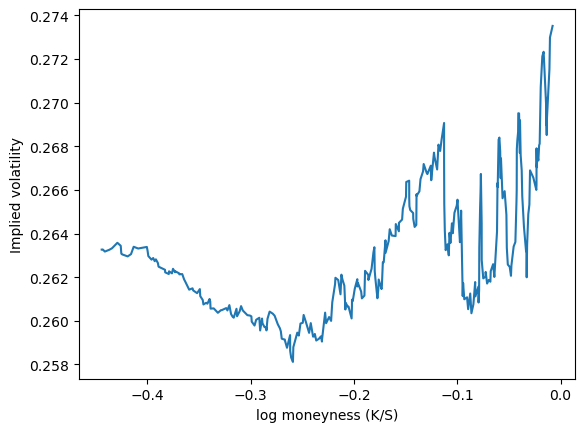

In [11]:
df = pd.DataFrame({"x": log_moneyness, "iv": ivs})
df = df.sort_values("x")
df["iv_smooth"] = df["iv"].rolling(30, center=True).mean()

plt.plot(df["x"], df["iv_smooth"])
plt.xlabel("log moneyness (K/S)")
plt.ylabel("Implied volatility")
plt.show()

#### Call Option Volatility Surface

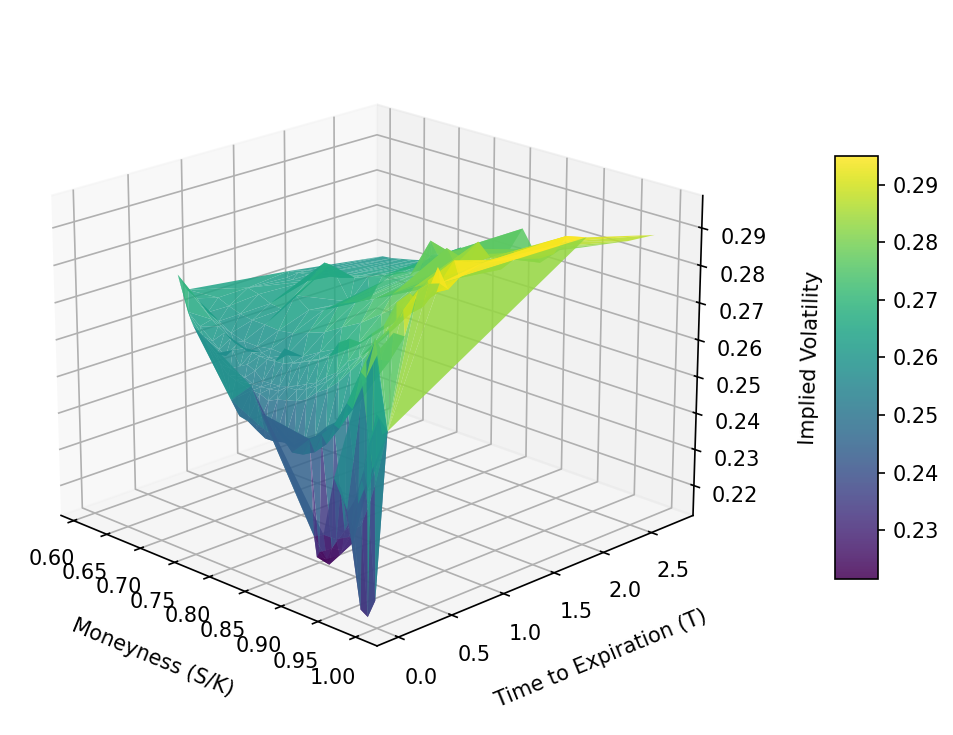

In [12]:
%matplotlib inline  

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=150,
    subplot_kw={"projection": "3d"}
)

surf = ax.plot_trisurf(
    moneyness,
    dtes,
    ivs,
    cmap="viridis",
    linewidth=0.2,
    antialiased=True,
    alpha=0.85
)

ax.set_xlabel("Moneyness (S/K)", labelpad=10)
ax.set_ylabel("Time to Expiration (T)", labelpad=10)
ax.set_zlabel("Implied Volatility", labelpad=10)

ax.view_init(elev=20, azim=-45)

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, pad=0.1)

plt.tight_layout()
plt.show()

#### Put Option Volatility Smile

In [13]:
ivs, moneyness, log_moneyness, dtes = getVol(all_puts, 'p')

Warning. Incompatible vol found. Vol =  4.99999999996362


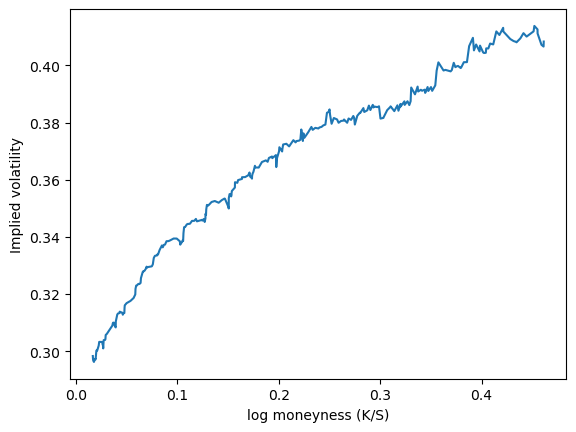

In [14]:
df = pd.DataFrame({"x": log_moneyness, "iv": ivs})
df = df.sort_values("x")
df["iv_smooth"] = df["iv"].rolling(30, center=True).mean()

plt.plot(df["x"], df["iv_smooth"])
plt.xlabel("log moneyness (K/S)")
plt.ylabel("Implied volatility")
plt.show()

#### Put Option Volatility Surface

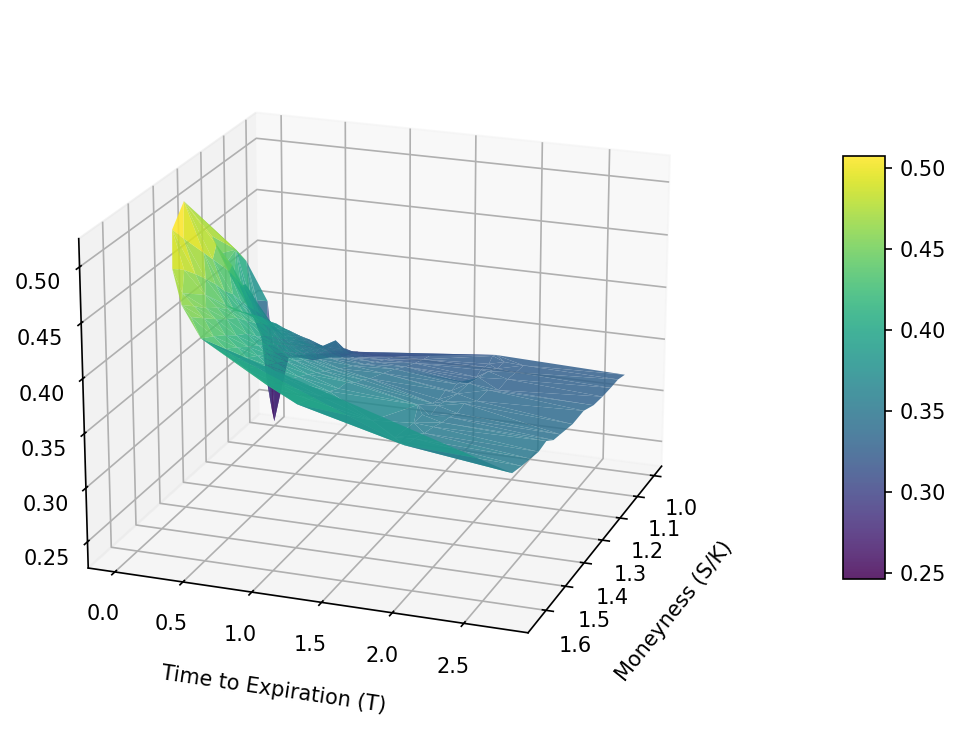

In [15]:
%matplotlib inline  

fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=150,
    subplot_kw={"projection": "3d"}
)

surf = ax.plot_trisurf(
    moneyness,
    dtes,
    ivs,
    cmap="viridis",
    linewidth=0.2,
    antialiased=True,
    alpha=0.85
)

ax.set_xlabel("Moneyness (S/K)", labelpad=10)
ax.set_ylabel("Time to Expiration (T)", labelpad=10)
ax.set_zlabel("Implied Volatility", labelpad=10)

ax.view_init(elev=20, azim=20)

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, pad=0.1)

plt.tight_layout()
plt.show()